In [1]:
#libraries
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler,Subset
from sklearn.metrics import classification_report

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    roc_curve, multilabel_confusion_matrix
)
from tqdm import tqdm

import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import random
import math

import soundfile as sf

#perch2.0 imports"
import tensorflow as tf
import tensorflow_hub as hub


c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:

#load perch 2.0
perch_url = "https://www.kaggle.com/models/google/bird-vocalization-classifier/frameworks/TensorFlow2/variations/perch_v2/versions/1"
perch_model = hub.load(perch_url)

In [ ]:
#Data preprocessing

class BatAudioPipeline(torch.nn.Module):
    # CHANGED: target_sr to 32000 and window_sec to 5
    def __init__(self, target_sr=32000, expansion_factor=5, window_sec=5.0, overlap=0.5):
        super().__init__()
        self.target_sr = target_sr
        self.expansion_factor = expansion_factor
        
        # Windowing parameters (160,000 samples for 5s @ 32kHz)
        self.win_samples = int(window_sec * target_sr)
        self.hop_samples = int(self.win_samples * (1.0 - overlap))

    def load_and_expand(self, file_path):
        try:
            data, orig_sr = sf.read(file_path)
            audio = torch.from_numpy(data).float()
            if audio.ndim == 1:
                audio = audio.unsqueeze(0)
            else:
                audio = audio.transpose(0, 1)

            if audio.shape[0] > 1:
                audio = torch.mean(audio, dim=0, keepdim=True)

            # 10x Time Expansion logic
            virtual_sr = orig_sr // self.expansion_factor

            # CHANGED: Resampling to 32kHz for Perch
            if virtual_sr != self.target_sr:
                audio = F.resample(audio, orig_freq=virtual_sr, new_freq=self.target_sr)

            return audio
        except Exception as e:
            print(f"\n[Warning] Skipping {file_path}: {e}")
            return torch.zeros((1, self.target_sr))

    def apply_bandpass(self, audio):
        # Highpass remains at 1.5kHz (expanded domain), 
        # but sample_rate is now 32000
        return F.highpass_biquad(audio, sample_rate=self.target_sr, cutoff_freq=1500.0/self.expansion_factor)

    # ... [Keep generate_colored_noise, add_noise_snr, random_gain the same] ...

    def window_audio(self, audio):
        if audio.shape[1] < self.win_samples:
            pad_amount = self.win_samples - audio.shape[1]
            audio = torch.nn.functional.pad(audio, (0, pad_amount))
            
        windows = audio.unfold(-1, self.win_samples, self.hop_samples)
        windows = windows.transpose(0, 1)
        return windows

    def to_raw_windows(self, windows):
        """Prepares windows for Perch."""
        # Remove channel dim: [Num_Windows, Samples]
        windows = windows.squeeze(1)

        # Perch is robust, but usually expects audio in [-1, 1] range.
        # Peak normalization is safer for Perch than Z-score normalization.
        max_vals, _ = torch.max(torch.abs(windows), dim=-1, keepdim=True)
        normalized_windows = windows / (max_vals + 1e-8)

        return normalized_windows

    def forward(self, file_path, noise_path=None, augment=False):
        audio = self.load_and_expand(file_path)
        audio = self.apply_bandpass(audio)
        
        if augment:
            audio = self.random_gain(audio, min_db=-12.0, max_db=6.0)
            # [Insert your noise mixing logic here]

        windows = self.window_audio(audio)
        specs = self.to_raw_windows(windows)
        
        return specs

In [4]:

class PerchEncoder:
    def __init__(self):
        # Load the model from Kaggle
        model_url = "https://www.kaggle.com/models/google/bird-vocalization-classifier/frameworks/TensorFlow2/variations/perch_v2_cpu/versions/1"
        self.model = hub.load(model_url)
        self.infer = self.model.signatures['serving_default']

    def extract(self, torch_windows):
        """
        Takes PyTorch tensor [Num_Windows, 160000], 
        returns Numpy embeddings [Num_Windows, 1536]
        """
        # Convert Torch to Numpy
        np_windows = torch_windows.cpu().numpy()
        
        # Perch expects [Batch, Samples]
        # We process the windows as a single batch
        outputs = self.infer(inputs=tf.convert_to_tensor(np_windows))
        
        # 'embedding' is the 1536-dim feature vector
        return outputs['embedding'].numpy()

In [5]:

class PipistrelleDataset(Dataset):
    def __init__(self, csv_file, root_dir, encoder=None, noise_folder=None, is_training=True):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.is_training = is_training
        self.encoder = encoder  # This will be our PerchEncoder
        
        # Initialize pipeline with 32kHz
        self.pipeline = BatAudioPipeline(target_sr=32000, expansion_factor=10, window_sec=5.0)
        
        # [Noise file loading logic...]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = os.path.join(self.root_dir, row['relative_path'])
        
        # 1. Get raw audio windows [Num_Windows, 160000]
        windows_tensor = self.pipeline(file_path, augment=self.is_training)
        
        # 2. Pass through Perch Encoder if provided
        if self.encoder is not None:
            # Returns [Num_Windows, 1536]
            features = self.encoder.extract(windows_tensor)
            
            # Pool features into a single vector for the SVM [1536]
            # Max pooling across windows is best for rare bat calls
            final_features = np.max(features, axis=0)
        else:
            final_features = windows_tensor

        labels = torch.tensor([
            row['type_a'], row['type_b'], row['type_c'], 
            row['type_d'], row['echo']
        ], dtype=torch.float32)
        
        return torch.from_numpy(final_features), labels

In [6]:
# 1. Initialize Perch
perch = PerchEncoder()

# 2. Create Dataset
dataset = PipistrelleDataset(
    csv_file='bat_metadata.csv', 
    root_dir='C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset', 
    encoder=perch,
    is_training=False # Set to True for SVM training data
)


In [7]:
import gc

def extract_robustly(dataset, save_path="perch_features.npz"):
    all_features = []
    all_labels = []
    
    # Process files one by one to keep memory footprint low
    for i in tqdm(range(len(dataset))):
        # 1. Get data
        features, labels = dataset[i] 
        
        # 2. Convert to Numpy IMMEDIATELY 
        # (This breaks the connection to the TensorFlow/Torch graphs)
        all_features.append(features.detach().cpu().numpy())
        all_labels.append(labels.numpy())
        
        # 3. Force Garbage Collection every 20 files
        if i % 20 == 0:
            tf.keras.backend.clear_session() # Clear TF cache
            gc.collect() # Force Python to free RAM
            
    # Save the final arrays
    np.savez_compressed(save_path, features=np.array(all_features), labels=np.array(all_labels))

In [8]:
# Usage
extract_robustly(dataset)

  0%|          | 0/284 [00:00<?, ?it/s]


100%|██████████| 284/284 [2:16:26<00:00, 28.82s/it]  


In [6]:
def create_composition_labels(y_matrix, label_names):
    comp_labels = []
    for row in y_matrix:
        active = [label_names[i] for i, val in enumerate(row) if val == 1]
        if not active:
            comp_labels.append("Silence/Other")
        else:
            comp_labels.append(" + ".join(active))
    return comp_labels


In [7]:
import matplotlib.colors as mcolors

# 1. Define distinct base colors for your 5 categories
base_colors = {
    'Type A': '#1f77b4', # Blue
    'Type B': '#ff7f0e', # Orange
    'Type C': '#2ca02c', # Green
    'Type D': '#d62728', # Red
    'Echo':   '#9467bd'  # Purple
}

def mix_multi_labels(row, label_names, base_colors):
    """
    Finds all active labels in a row and averages their RGB colors.
    """
    active_indices = [i for i, val in enumerate(row) if val == 1]
    
    if not active_indices:
        return mcolors.to_rgb('#e0e0e0') # Light grey for unlabeled/silence
    
    # Get RGB tuples for all active labels
    rgbs = [mcolors.to_rgb(base_colors[label_names[i]]) for i in active_indices]
    
    # Average the RGB values
    mixed_rgb = np.mean(rgbs, axis=0)
    return mixed_rgb


c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running PCA...
Running UMAP...
Running t-SNE...


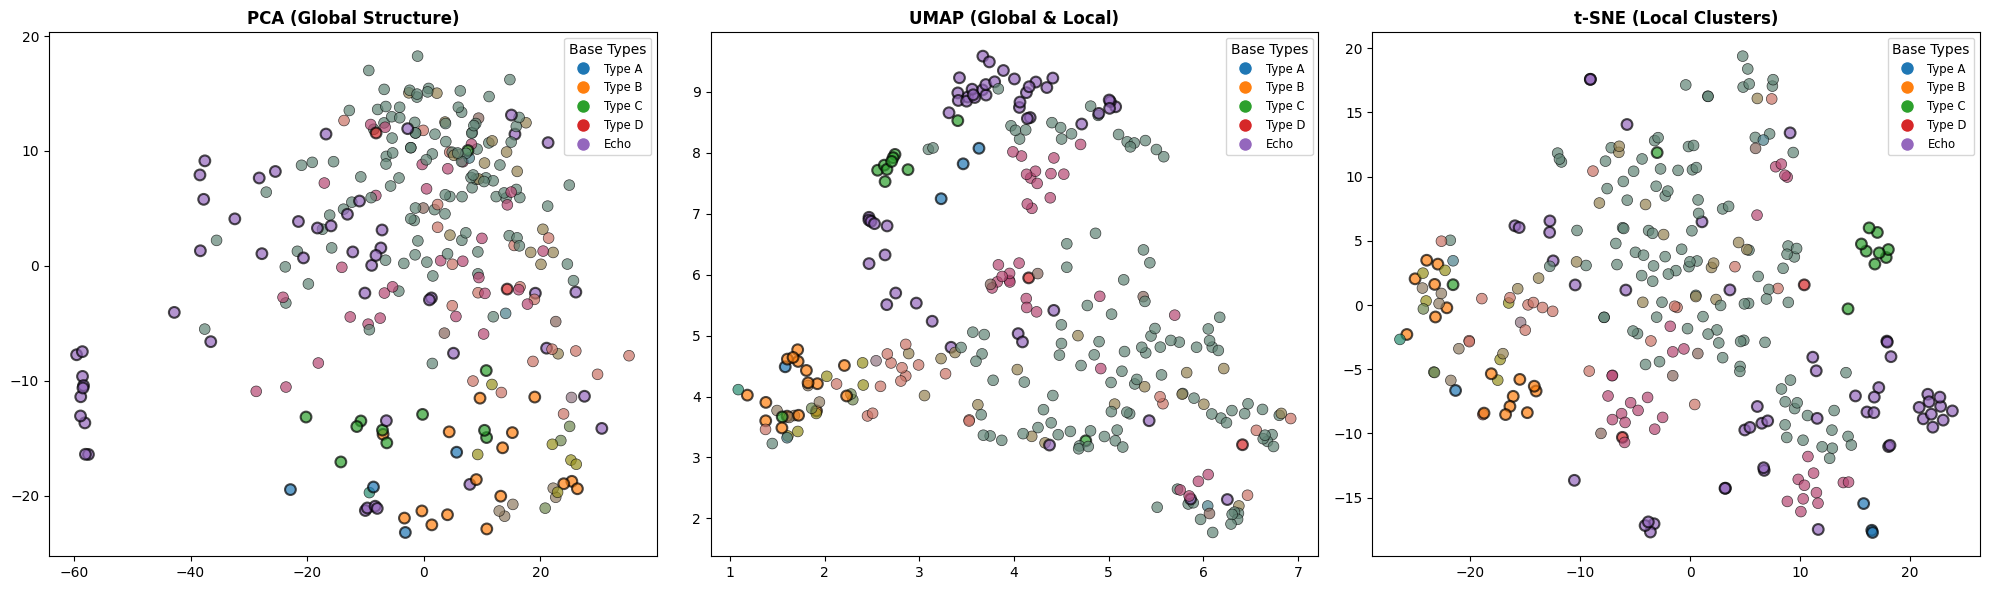

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
import umap

# 1. Load Data
data = np.load("perch_features.npz")
X = data['features']
y = data['labels'] # Shape [N, 5] (A, B, C, D, Echo)

# --- Label Prep ---
# Create a single 'Class' label for coloring. 
# We'll pick the first active 'Type' column, or 'None' if all 0.
#label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
#def get_primary_label(row):
#    for i, val in enumerate(row):
#        if val == 1: return label_names[i]
#    return 'Other/Silence'
#
#color_labels = [get_primary_label(row) for row in y]

# Usage
label_names = ['A', 'B', 'C', 'D', 'Echo']
color_labels = create_composition_labels(y, label_names)
# Generate the color array for your data
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
point_colors = [mix_multi_labels(row, label_names, base_colors) for row in y]

# Now use 'color_labels' in the sns.scatterplot(hue=color_labels) 
# code from the previous step.

# 2. Preprocessing (Standard Scaling is CRITICAL)
X_scaled = StandardScaler().fit_transform(X)

# 3. Apply Dimensionality Reduction
print("Running PCA...")
pca_res = PCA(n_components=2).fit_transform(X_scaled)

print("Running UMAP...")
umap_res = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine').fit_transform(X_scaled)

print("Running t-SNE...")
tsne_res = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto').fit_transform(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['PCA (Global Structure)', 'UMAP (Global & Local)', 't-SNE (Local Clusters)']
results = [pca_res, umap_res, tsne_res]

for i, res in enumerate(results):
    ax = axes[i]
    
    
    edge_widths = [1.5 if row.sum() == 1 else 0.5 for row in y]
    
    # Use ax.scatter instead of sns.scatterplot
    # This allows us to pass our mixed 'point_colors' directly to 'c'
    ax.scatter(
        res[:, 0], res[:, 1], 
        c=point_colors, 
        s=60, alpha=0.7, 
        edgecolor='black', 
        linewidth=edge_widths
    )
    
    ax.set_title(titles[i], fontweight='bold')
    
    # Since we aren't using Seaborn's auto-legend, we add a manual one
    # using the base_colors dictionary we defined earlier
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=10) 
        for k, v in base_colors.items()
    ]
    ax.legend(handles=legend_elements, title="Base Types", loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

In [9]:
print(data['features'].shape)

(284, 1536)


In [11]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, accuracy_score, f1_score, hamming_loss

# 1. Pipeline (Scaling + Model)
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', OneVsRestClassifier(SVC(kernel='rbf', C=3.0, gamma='scale')))
])

# 2. Add 'accuracy' to our scoring dictionary
scoring = {
    'accuracy': 'accuracy',  # Sklearn handles 'accuracy' as subset accuracy for multi-label
    'f1_micro': 'f1_micro',
    'f1_macro': 'f1_macro',
    'hamming': make_scorer(hamming_loss)
}

# 3. Run Cross-Validation
print("Calculating cross-validated scores...")
cv_results = cross_validate(
    model_pipeline, X, y, 
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring
)

# 4. Detailed Results
print("\n" + "="*35)
print("   SCIENTIFIC BASELINE SUMMARY")
print("="*35)
# Note: test_accuracy refers to Subset Accuracy in multi-label
mean_acc = np.mean(cv_results['test_accuracy'])
std_acc = np.std(cv_results['test_accuracy'])

print(f"Subset Accuracy:  {mean_acc:.2%} (+/- {std_acc:.2%})")
print(f"Mean Macro F1:    {np.mean(cv_results['test_f1_macro']):.4f}")
print(f"Mean Hamming:     {np.mean(cv_results['test_hamming']):.4f}")
print("="*35)
print("> Note: Subset Accuracy requires an EXACT match of all 5 labels.")

Calculating cross-validated scores...

   SCIENTIFIC BASELINE SUMMARY
Subset Accuracy:  77.12% (+/- 3.10%)
Mean Macro F1:    0.7634
Mean Hamming:     0.0577
> Note: Subset Accuracy requires an EXACT match of all 5 labels.


In [63]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE DATA
# This brings back your 1536-dim features and your binary labels
data = np.load("perch_features.npz")
X = data['features']
y = data['labels']
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

# 2. SPLIT THE DATA
# We set aside 20% for testing (X_test, y_test)
# 'random_state=42' ensures you get the same split every time you run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. SCALE THE DATA (Standardization)
# We 'fit' the scaler on training data and 'transform' both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. INITIALIZE AND TRAIN THE SVM (svm_rbf)
# probability=True is required for ROC-AUC curves later
svm_rbf = OneVsRestClassifier(
    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
)

print("Training the Multi-label SVM...")
svm_rbf.fit(X_train_scaled, y_train)
print("Model trained and variables (X_test_scaled, y_test) are ready!")

Training the Multi-label SVM...
Model trained and variables (X_test_scaled, y_test) are ready!


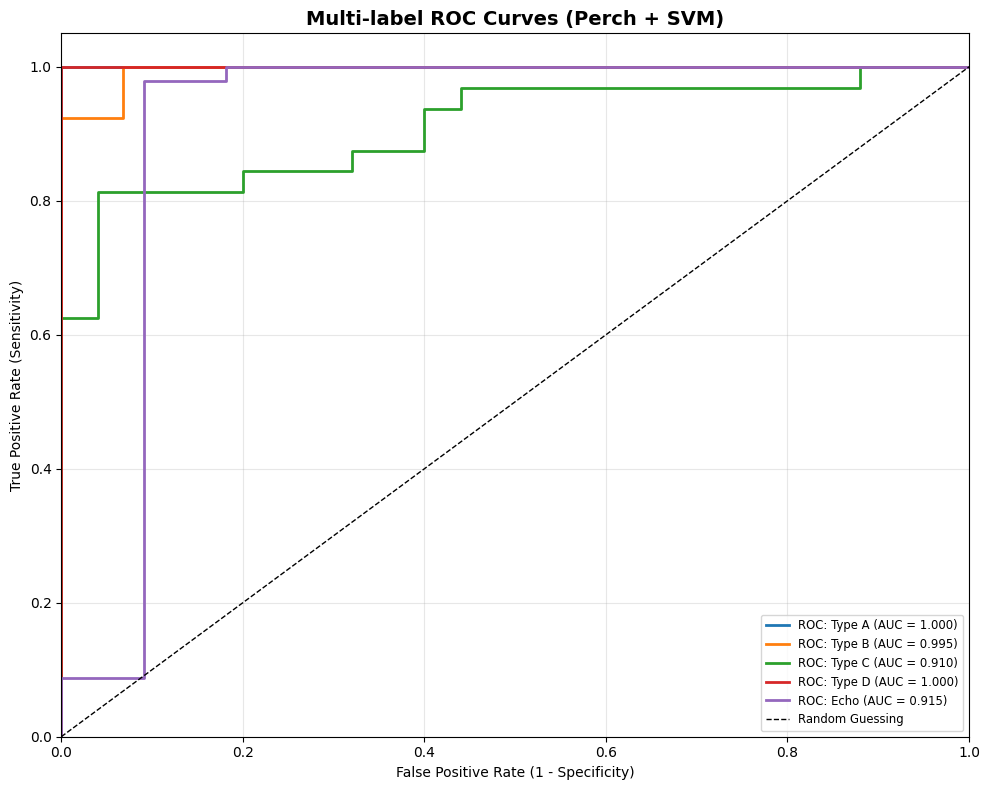

In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities
# shape will be (n_samples, 5)
y_score = svm_rbf.predict_proba(X_test_scaled)

# 2. Calculate ROC and AUC for each label
fpr = dict()
tpr = dict()
roc_auc = dict()
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 8))

for i in range(len(label_names)):
    # Compute ROC curve and AUC for each class
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot the curve
    plt.plot(
        fpr[i], tpr[i], color=colors[i], lw=2,
        label=f'ROC: {label_names[i]} (AUC = {roc_auc[i]:0.3f})'
    )

# 3. Plot the "Chance" line (diagonal)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')

# 4. Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-label ROC Curves (Perch + SVM)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right", fontsize='small')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score

# 1. Define the Architecture again
class BatProbe(nn.Module):
    def __init__(self, input_dim=1536, output_dim=5):
        super(BatProbe, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# 1. LOAD THE DATA
# This brings back your 1536-dim features and your binary labels
data = np.load("perch_features.npz")
X = data['features']
y = data['labels']
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

# 2. Setup CV parameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1s = []

print(f"Starting 5-Fold CV for Neural Probe...\n")

# 3. Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Create Fold Data
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]
    
    # Scale within the fold (to avoid data leakage)
    scaler = StandardScaler()
    X_train_f = torch.FloatTensor(scaler.fit_transform(X_train_f))
    X_val_f = torch.FloatTensor(scaler.transform(X_val_f))
    y_train_f = torch.FloatTensor(y_train_f)
    
    # Initialize Model, Loss, Optimizer for THIS fold
    probe = BatProbe()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(probe.parameters(), lr=0.001)
    
    # Simple Training Loop for the fold
    probe.train()
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = probe(X_train_f)
        loss = criterion(outputs, y_train_f)
        loss.backward()
        optimizer.step()
    
    # Evaluate on the validation fold
    probe.eval()
    with torch.no_grad():
        val_outputs = probe(X_val_f)
        preds = (val_outputs > 0.6).int().numpy()
        
    # Calculate metrics
    acc = accuracy_score(y_val_f, preds)
    f1 = f1_score(y_val_f, preds, average='macro')
    
    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    print(f"Fold {fold+1}: Accuracy = {acc:.2%}, F1 = {f1:.4f}")

# 4. Final Summary
print("\n" + "="*30)
print("   NN PROBE CV SUMMARY")
print("="*30)
print(f"Mean Subset Accuracy: {np.mean(fold_accuracies):.2%} (+/- {np.std(fold_accuracies):.2%})")
print(f"Mean Macro F1:        {np.mean(fold_f1s):.4f}")




Starting 5-Fold CV for Neural Probe...

Fold 1: Accuracy = 84.21%, F1 = 0.9521
Fold 2: Accuracy = 77.19%, F1 = 0.7016
Fold 3: Accuracy = 80.70%, F1 = 0.8507
Fold 4: Accuracy = 71.93%, F1 = 0.8356
Fold 5: Accuracy = 82.14%, F1 = 0.8835

   NN PROBE CV SUMMARY
Mean Subset Accuracy: 79.24% (+/- 4.31%)
Mean Macro F1:        0.8447


In [67]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import average_precision_score

print("--- Retrieval Evaluation (Query-by-Example) ---")

# 1. Calculate cosine similarity between all Test clips and Train clips
# Shape will be (N_test, N_train)
similarities = cosine_similarity(X_test_scaled, X_train_scaled)

label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
class_retrieval_scores = []

# 2. Loop through each label to evaluate retrieval performance
for i, label in enumerate(label_names):
    # Find test clips that actually contain this label (our "Queries")
    query_indices = np.where(y_test[:, i] == 1)[0]
    
    if len(query_indices) == 0:
        print(f"{label}: No queries in test set.")
        continue
        
    query_aps = []
    for q_idx in query_indices:
        # The similarity scores from this query to all training samples
        sim_scores = similarities[q_idx]
        
        # Ground truth: which training samples have this label? (1 or 0)
        true_matches = y_train[:, i]
        
        # Calculate Average Precision for this specific query
        ap = average_precision_score(true_matches, sim_scores)
        query_aps.append(ap)
    
    mean_class_ap = np.mean(query_aps)
    class_retrieval_scores.append(mean_class_ap)
    print(f"Retrieval mAP for {label}: {mean_class_ap:.4f}")

# Overall Retrieval Score
print(f"\nMean Retrieval mAP (All Classes): {np.mean(class_retrieval_scores):.4f}")

--- Retrieval Evaluation (Query-by-Example) ---
Retrieval mAP for Type A: 0.3387
Retrieval mAP for Type B: 0.6200
Retrieval mAP for Type C: 0.6397
Retrieval mAP for Type D: 0.4396
Retrieval mAP for Echo: 0.8989

Mean Retrieval mAP (All Classes): 0.5874


In [69]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

print("--- Retrieval Evaluation (Query-by-Example AUC) ---")

# 1. Calculate cosine similarity between all Test clips and Train clips
# Shape will be (N_test, N_train)
similarities = cosine_similarity(X_test_scaled, X_train_scaled)

label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
class_retrieval_aucs = []

# 2. Loop through each label to evaluate retrieval performance
for i, label in enumerate(label_names):
    # Find test clips that actually contain this label (our "Queries")
    query_indices = np.where(y_test[:, i] == 1)[0]
    
    if len(query_indices) == 0:
        print(f"{label}: No queries in test set.")
        continue
        
    query_aucs = []
    for q_idx in query_indices:
        # The similarity scores from this query to all training samples
        sim_scores = similarities[q_idx]
        
        # Ground truth: which training samples have this label? (1 or 0)
        true_matches = y_train[:, i]
        
        # Check if the training set has both positives and negatives for this label
        # (ROC-AUC mathematically requires at least one 0 and one 1 in the truth array)
        if len(np.unique(true_matches)) > 1:
            # Calculate the AUC for this single query's retrieval ranking
            auc = roc_auc_score(true_matches, sim_scores)
            query_aucs.append(auc)
    
    # Average the AUCs across all queries for this specific bat type
    if query_aucs:
        mean_class_auc = np.mean(query_aucs)
        class_retrieval_aucs.append(mean_class_auc)
        print(f"Retrieval AUC for {label}: {mean_class_auc:.4f}")
    else:
        print(f"Retrieval AUC for {label}: N/A")

# 3. Overall Retrieval Score
if class_retrieval_aucs:
    print(f"\nMean Retrieval AUC (All Classes): {np.mean(class_retrieval_aucs):.4f}")

--- Retrieval Evaluation (Query-by-Example AUC) ---
Retrieval AUC for Type A: 0.7782
Retrieval AUC for Type B: 0.7901
Retrieval AUC for Type C: 0.6107
Retrieval AUC for Type D: 0.7324
Retrieval AUC for Echo: 0.6358

Mean Retrieval AUC (All Classes): 0.7094


In [70]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

def calculate_r_auc(X_train, y_train, X_test, y_test):
    # 1. Similarity Matrix (Test vs Train)
    sim_matrix = cosine_similarity(X_test, X_train)
    
    query_aucs = []
    
    # 2. Iterate through every clip in the test set as a query
    for i in range(len(X_test)):
        query_labels = y_test[i]
        
        # PAPER RULE: Exclude queries with no labels
        if np.sum(query_labels) == 0:
            continue
            
        # PAPER RULE: Relevant if they share AT LEAST ONE label
        # We use a dot product to see if there is any overlap
        # binary_relevance will be 1 if overlap > 0, else 0
        relevance_scores = np.dot(y_train, query_labels)
        binary_relevance = (relevance_scores > 0).astype(int)
        
        # Get the similarities for this specific query
        query_sims = sim_matrix[i]
        
        # PAPER RULE: Ground-truth items with no labels are included as negatives
        # (This is handled automatically because their dot product with any query is 0)
        
        # Calculate ROC AUC for this query
        if len(np.unique(binary_relevance)) > 1:
            auc = roc_auc_score(binary_relevance, query_sims)
            query_aucs.append(auc)
            
    return np.mean(query_aucs)

# Usage
r_auc_score = calculate_r_auc(X_train_scaled, y_train, X_test_scaled, y_test)
print(f"Global R-AUC (Ghani et al. Method): {r_auc_score:.4f}")

Global R-AUC (Ghani et al. Method): 0.6654


In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

print("\n--- Clustering Evaluation (NMI) ---")

# 1. Convert multi-label arrays into single strings (Label Powerset)
# Example: [1, 0, 0, 0, 1] becomes "1-0-0-0-1"
def get_powerset_labels(y_matrix):
    return np.array(['-'.join(map(str, row)) for row in y_matrix])

# We'll evaluate NMI on the entire dataset to get the best representation of the space
X_all_scaled = np.vstack((X_train_scaled, X_test_scaled))
y_all = np.vstack((y_train, y_test))

y_str_labels = get_powerset_labels(y_all)

# 2. Count how many unique combinations actually exist in your data
unique_combinations = np.unique(y_str_labels)
n_clusters = len(unique_combinations)
print(f"Found {n_clusters} unique label combinations (e.g., Species + Echo)")

# 3. Unsupervised Clustering (K-Means)
# We force K-Means to find 'n_clusters' groups based ONLY on the audio features
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(X_all_scaled)

# 4. Calculate NMI
# Compares the unsupervised clusters to the ground-truth string labels
nmi_score = normalized_mutual_info_score(y_str_labels, cluster_assignments)

print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")


--- Clustering Evaluation (NMI) ---
Found 16 unique label combinations (e.g., Species + Echo)
Normalized Mutual Information (NMI): 0.4270
